<div align="center">
    <h1>Introduction to Mathematical Programming</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/AzAINN">Azain Khalid</a>
    <br>
    <i>Department of Computer Science, Purdue University</i>
    <br>
    <i>Undergraduate Researcher</i>
    <br>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_jl/1-MathProg.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

**Environment setup**

For local execution from the repository root, run `make setup-julia NOTEBOOK=notebooks_jl/1-MathProg.ipynb` before launching Jupyter. This notebook now uses its own Julia project under `notebooks_jl/envs/1-MathProg/`, so it does not install the QUBO and D-Wave stack.

This notebook should open directly with the **Julia** runtime in Google Colab. If it does not, switch the runtime before running the next cell.
The setup cell will clone `SECQUOIA/QuIP` into the Colab workspace when needed, activate `notebooks_jl/envs/1-MathProg/Project.toml`, instantiate only the Julia packages used in this notebook, and print progress for clone, activate, instantiate, and package-load steps. Package precompilation still happens as needed during setup. The first Colab run can still take several minutes.


In [ ]:
function load_notebook_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QuIP", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QuIP", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUIP_REPO_DIR", joinpath(pwd(), "QuIP"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning SECQUOIA/QuIP into $repo_dir")
            run(`git clone --depth 1 https://github.com/SECQUOIA/QuIP.git $repo_dir`)
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_notebook_bootstrap()

BOOTSTRAP = Base.invokelatest(QuIPNotebookBootstrap.bootstrap_notebook, "1-MathProg")

QUIP_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab


## Mathematical Programming (Julia)

### Modeling
The solution to optimization problems requires the development of a mathematical model. Here we will model an example given in the lecture and see how an integer program can be solved practically.
This example will use as modeling language **[JuMP](http://jump.dev/)**.
This open-source Julia package provides flexible access to different solvers and a general modeling framework for linear and nonlinear integer programs.
The examples solved here will make use of open-source solvers **[GLPK](https://www.gnu.org/software/glpk/)** and **[HiGHS](https://highs.dev/)** for linear and mixed-integer linear programming, **[IPOPT](https://coin-or.github.io/Ipopt/)** for interior-point (non)linear programming, **[BONMIN](https://www.coin-or.org/Bonmin/)** for convex integer nonlinear programming, and **[COUENNE](https://github.com/coin-or/Couenne)** together with **[SCIP](https://www.scipopt.org/)** for nonconvex integer nonlinear programming.


#### Problem statement

Suppose there is a company that produces two different products, A and B, which can be sold at different values, $\$5.5$ and $\$2.1$ per unit, respectively.
The company only counts with a single machine with electricity usage of at most 17kW/day. Producing each A and B consumes $8\text{kW}/\text{day}$ and $2\text{kW}/\text{day}$, respectively.
Besides, the company can only produce at most $2$ more units of B than A per day.

### Linear Programming
This is a valid model, but it would be easier to solve if we had a mathematical representation.
Assuming the units produced of A are $x_1$ and of B are $x_2$ we have

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \le x_1 + 2 \\
                    & 8x_1 + 2x_2 \le 17 \\
                    & x_1, x_2 \ge 0
\end{array}
$$

In [ ]:
if !@isdefined(Plots)
    using Plots
end


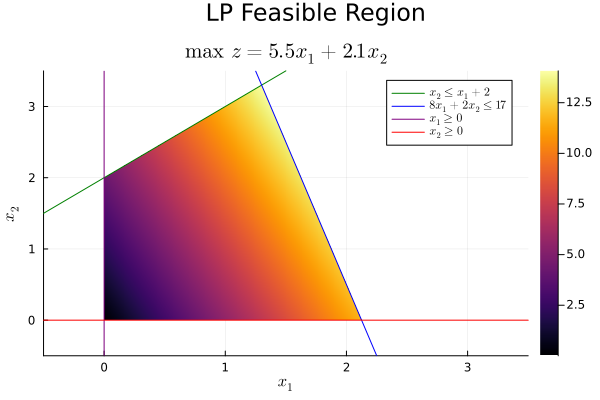

In [3]:
function plot_lp(;ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="LP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: max 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)      && # Bound: x1 ≥ 0
                         (x2 >= 0)      && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2) && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17) # Constraint 2: 8 x₁ + 2 x₂ ≤ 17

    # Heatmap function
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)

    # Plot feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ \max ~ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_lp()

In [ ]:
if !@isdefined(JuMP)
    using JuMP
end


In [5]:
# Define empty model
lp_model = Model()

# Define the variables
@variable(lp_model, x[1:2] >= 0)

# Define the objective function
@objective(lp_model, Max, 5.5x[1] + 2.1x[2])

# Define the constraints
@constraint(lp_model, c1, x[2] <= x[1] + 2)

@constraint(lp_model, c2, 8x[1] + 2x[2] <= 17)

# Print the model
print(lp_model)

In [ ]:
if !@isdefined(GLPK)
    using GLPK
end


In [7]:
# Here we solve the optimization problem with GLPK
set_optimizer(lp_model, GLPK.Optimizer)

set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")

We observe that the optimal solution of this problem is $(x_1, x_2) = (1.3, 3.3)$, leading to a profit of $14.08$.


In [ ]:
if !@isdefined(HiGHS)
    using HiGHS
end


In [ ]:
# With HiGHS instead:
set_optimizer(lp_model, HiGHS.Optimizer)

set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")


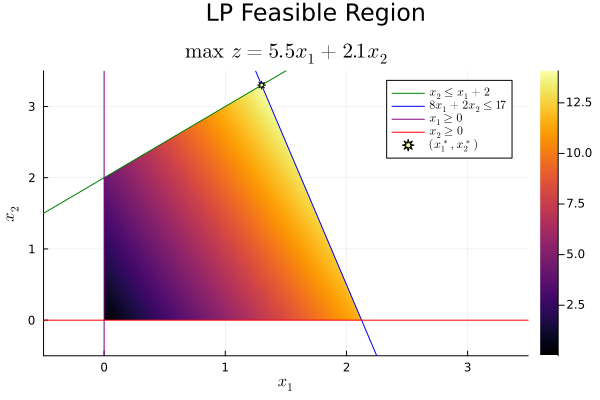

In [10]:
plot_lp(;sol = lp_x)

HiGHS recovers the same LP optimum as GLPK. GLPK and HiGHS are open-source LP/MIP solvers, and HiGHS is a good default for this notebook. We can also solve the LP relaxation with the interior-point solver IPOPT, which extends naturally to nonlinear programs. In mixed-integer models, however, IPOPT alone is not enough because it does not enforce integrality.


In [ ]:
if !@isdefined(Ipopt)
    using Ipopt
end


In [12]:
# Using Ipopt for an interior point method
set_optimizer(lp_model, Ipopt.Optimizer)
set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")

We obtain the same result as previously, but notice that the interior point method reports a solution subject to a certain tolerance, given by its convergence properties when it can get infinitesimally close (but not directly at) the boundary of the feasible region.

The LP model is a useful baseline because it solves quickly, and it gives us a reference objective before we add nonlinear structure or impose integrality. It is also an upper bound on the later integer model.


### Nonlinear Programming

Before imposing integrality, we can add a convex nonlinear constraint while keeping the variables continuous. This gives the following nonlinear program (NLP):

$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& (x_2-1)^2 \leq 2 - x_1 \\
& x_1, x_2 \geq 0
\end{aligned}
$$


In [ ]:
function plot_nlp(; ns::Integer = 1_000, sol = nothing)
    plt = plot(;
        plot_title="NLP Feasible Region",
        plot_titlevspan=0.1,
    )

    x1 = x2 = range(-0.5, 3.5; length = ns)

    z(x1, x2) = 5.5x1 + 2.1x2

    isfeasible(x1, x2) = (x1 >= 0)           &&
                         (x2 >= 0)           &&
                         (x2 <= x1 + 2)      &&
                         (8x1 + 2x2 <= 17)   &&
                         ((x2 - 1)^2 <= 2 - x1)

    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )
    plot!(plt, 2 .- (x1 .- 1) .^ 2, x1;
        label=raw"$ (x_2 - 1)^2 \leq 2 - x_1 $",
        color=:orange,
    )
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    if sol !== nothing
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_nlp()


In [ ]:
# Define and solve the nonlinear program
nlp_model = copy(lp_model)
x = nlp_model[:x]
@constraint(nlp_model, c3, (x[2] - 1)^2 <= 2 - x[1])
print(nlp_model)

set_optimizer(nlp_model, Ipopt.Optimizer)
set_silent(nlp_model)

optimize!(nlp_model)

nlp_x = value.(x)

println(solution_summary(nlp_model))
println("* x = $nlp_x")


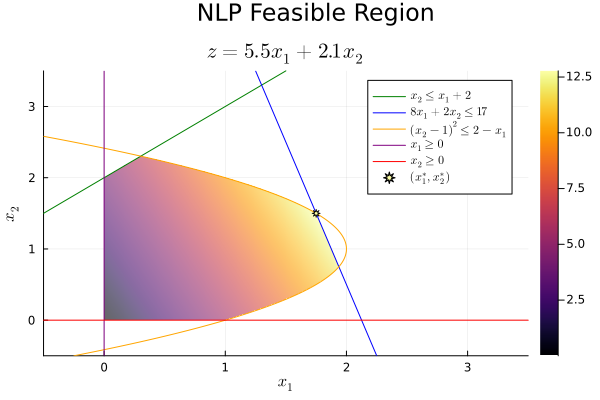

In [ ]:
plot_nlp(; sol = nlp_x)


Here the continuous NLP solution is approximately $(x_1, x_2) = (1.75, 1.50)$ with objective $12.775$. Compared with the LP solution, the convex nonlinear constraint bends the feasible region and lowers the optimum, but the problem is still continuous because no integrality has been imposed yet.


### Integer Programming

Now let's consider that only integer units of each product can be produced, namely

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \leq x_1 + 2 \\
                    & 8x_1 + 2x_2 \leq 17 \\
                    & x_1, x_2 \geq 0 \\
                    & x_1, x_2 \in \mathbb{Z}
\end{array}
$$

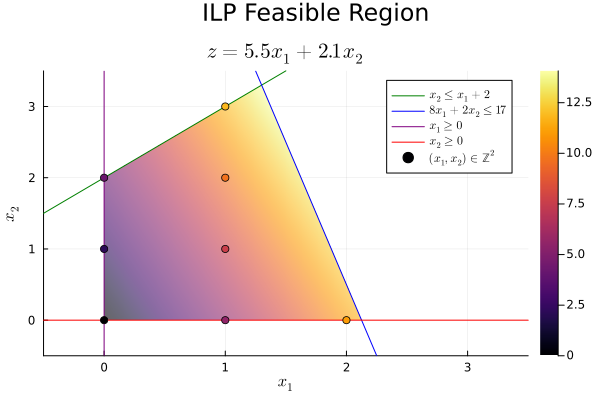

In [13]:
function plot_ilp(;ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="ILP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: max 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)      && # Bound: x1 ≥ 0
                         (x2 >= 0)      && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2) && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17) # Constraint 2: 8 x₁ + 2 x₂ ≤ 17

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2]) 

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_ilp()

In [14]:
# Copy model
ilp_model = copy(lp_model)

# Retrieve variable reference
x = ilp_model[:x]

# Add integrality contraint: x₁, x₂ ∈ ℤ
set_integer.(x)

# Print the model
print(ilp_model)

In [ ]:
set_optimizer(ilp_model, HiGHS.Optimizer)
set_silent(ilp_model)

optimize!(ilp_model)

# Retrieve the optimal integer solution
ilp_x = value.(x)

println(solution_summary(ilp_model))
println("* x = $ilp_x")


Here the solution becomes $(x_1, x_2) = (1, 3)$ with an objective of $11.8$. Compared with the LP relaxation, the integer restriction shrinks the feasible set, so the best achievable profit is lower.


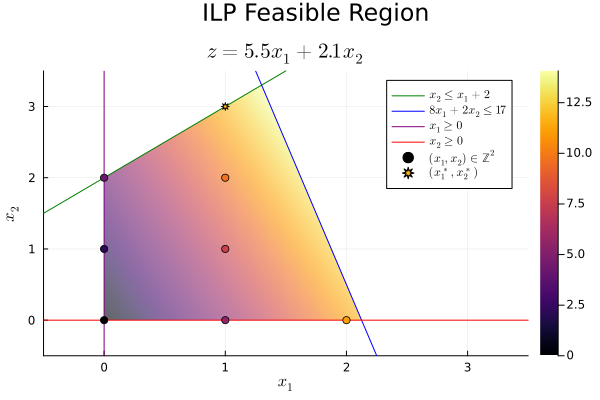

In [16]:
plot_ilp(; sol = ilp_x)

#### Enumeration
Enumerating all the possible solutions in this problem might be very efficient (there are only 8 feasible solutions), but we only know that from the plot. Assuming that we had upper bounds of 4 for both variables, the possible solutions would already rise to 16. With a larger number of variables, enumeration quickly becomes impractical. For $n$ binary variables (we can always "binarize" the integer variables), the number of possible solutions is $2^n$.

In many other applications, the possible solutions come from permutations of the integer variables (e.g., assignment problems), which grow as $n!$ with the size of the input.

This growth makes the problem get out of control fairly quickly.


In [ ]:
if !@isdefined(SpecialFunctions)
    using SpecialFunctions
end


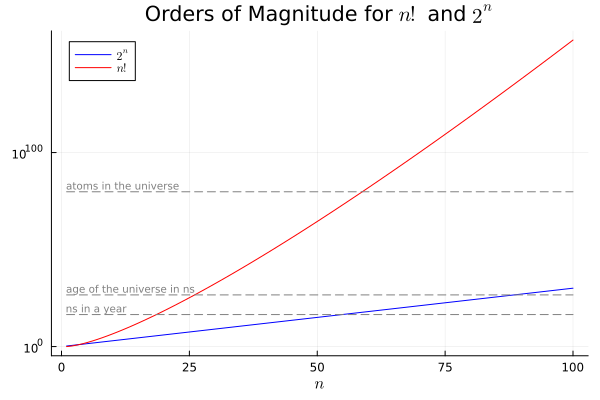

In [1]:
function plot_growth(n::Integer = 100)
    i = 1:n

    plt = plot(;
        title=raw"Orders of Magnitude for $ n! $ and $ 2^n $",
        xlabel=raw"$ n $",
        legend=:topleft,
        yscale=:log10,
    )

    plot!(plt, i, (i) -> 2.0^i; label=raw"$ 2^n $", color=:blue)
    plot!(plt, i, (i) -> SpecialFunctions.gamma(i + 1); label=raw"$ n! $", color=:red)

    plot!(plt, i, (i) -> 3.154E16; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 3.154E16, text("ns in a year", :gray, :left, :bottom, 7))

    plot!(plt, i, (i) -> 4.3E26; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 4.3E26, text("age of the universe in ns", :gray, :left, :bottom, 7))

    plot!(plt, i, (i) -> 6E79; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 6E79, text("atoms in the universe", :gray, :left, :bottom, 7))

    return plt
end

plot_growth()


### Integer convex nonlinear programming

If we keep the same convex nonlinear constraint and now require integer decisions, we obtain the following convex integer nonlinear program.

$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& (x_2-1)^2 \leq 2 - x_1 \\
& x_1, x_2 \geq 0 \\
& x_1, x_2 \in \mathbb{Z}
\end{aligned}
$$


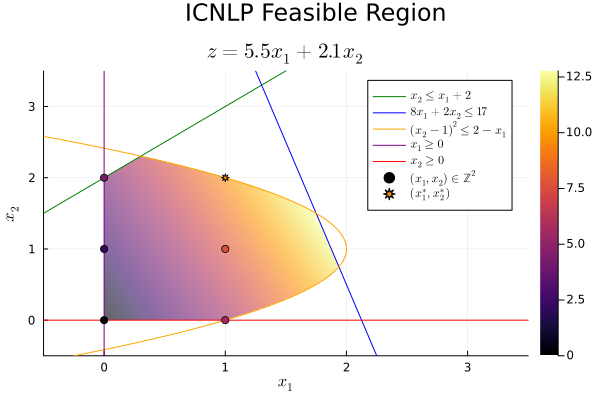

In [19]:
function plot_icnlp(; ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="ICNLP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: max 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)           && # Bound: x1 ≥ 0
                         (x2 >= 0)           && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2)      && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17)   && # Constraint 2: 8 x₁ + 2 x₂ ≤ 17
                         ((x2 - 1)^2 <= 2 - x1) # Constraint 3: (x₂ - 1)² ≤ 2 - x₁

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2]) 

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )
    plot!(plt, 2 .- (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \leq 2 - x_1 $",
        color=:orange,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_icnlp()

In [20]:
# Define the model
icnlp_model = copy(ilp_model)

# Retrieve variable reference
x = icnlp_model[:x]

# (x₂ - 1)² ≤ 2 - x₁
@constraint(icnlp_model, c3, (x[2] - 1)^2 <= 2 - x[1])

# Print the model
print(icnlp_model)

In [ ]:
# BONMIN solver
using AmplNLWriter
using Bonmin_jll

Bonmin_Optimizer() = AmplNLWriter.Optimizer(Bonmin_jll.amplexe);


In [22]:
set_optimizer(icnlp_model, Bonmin_Optimizer)

optimize!(icnlp_model)

icnlp_x = value.(x)

println(solution_summary(icnlp_model))
println("* x = $icnlp_x")

In this case the optimal solution becomes $(x_1, x_2) = (1, 2)$ with an objective of $9.7$. Compared with the continuous NLP, the same nonlinear geometry is still present, but the integer restriction removes the fractional optimum and lowers the best achievable profit again.


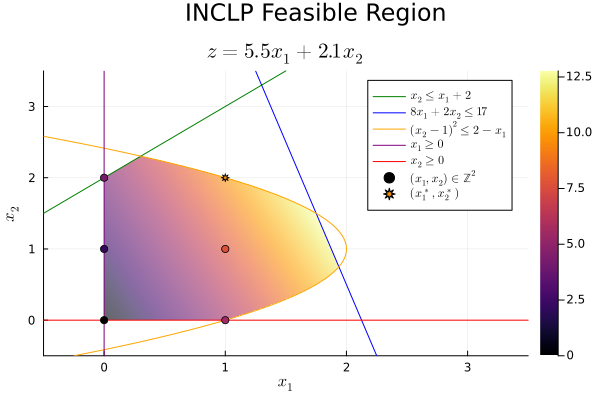

In [23]:
plot_icnlp(; sol = icnlp_x)

### Integer non-convex programming

The last constraint "the production of B minus 1 squared can only be greater than the production of A plus one half" can be incorporated in the following non-convex integer nonlinear program

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \leq x_1 + 2 \\
                    & 8x_1 + 2x_2 \leq 17 \\
                    & (x_2-1)^2 \leq 2-x_1 \\
                    & (x_2-1)^2 \geq \frac{1}{2} + x_1 \\
                    & x_1, x_2 \geq 0 \\
                    & x_1, x_2 \in \mathbb{Z}
\end{array}
$$


In [ ]:
function plot_incnlp(; ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="Nonconvex INLP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: max 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)              && # Bound: x1 ≥ 0
                         (x2 >= 0)              && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2)         && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17)      && # Constraint 2: 8 x₁ + 2 x₂ ≤ 17
                         ((x2 - 1)^2 <= 2 - x1) && # Constraint 3: (x₂ - 1)² ≤ 2 - x₁
                         ((x2 - 1)^2 >= 1/2 + x1)  # Constraint 4: (x₂ - 1)² ≥ 1/2 + x₁

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2])

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ \max ~ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )
    plot!(plt, 2 .- (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \leq 2 - x_1 $",
        color=:orange,
    )
    plot!(plt, -1/2 .+ (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \geq \frac{1}{2} + x_1 $",
        color=:magenta,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [round(sol[1])], [round(sol[2])];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_incnlp()

In [25]:
# Define the model
incnlp_model = copy(icnlp_model)

# Retrieve variable reference
x = incnlp_model[:x]

# (x₂ - 1)² ≥ 1/2 + x₁
@constraint(incnlp_model, c4, (x[2] - 1)^2 >= 1/2 + x[1])

# Print the model
print(incnlp_model)

In [ ]:
# Trying to solve the problem with BONMIN we might obtain a good solution,
# but we have no global guarantees
set_optimizer(incnlp_model, Bonmin_Optimizer)

optimize!(incnlp_model)

if result_count(incnlp_model) > 0
    incnlp_x = value.(x)

    println("* x = $incnlp_x")
end


In [ ]:
# Global MINLP solvers
using Couenne_jll
using SCIP

Couenne_Optimizer() = AmplNLWriter.Optimizer(Couenne_jll.amplexe);


In [ ]:
# Solve the global MINLP with COUENNE
set_optimizer(incnlp_model, Couenne_Optimizer)

optimize!(incnlp_model)

println(solution_summary(incnlp_model))

if result_count(incnlp_model) > 0
    incnlp_x = value.(x)

    println("* x = $incnlp_x")
end


In [ ]:
# Solve the same global MINLP directly with SCIP
scip_model = copy(incnlp_model)
x_scip = scip_model[:x]

set_optimizer(scip_model, SCIP.Optimizer)
set_silent(scip_model)

optimize!(scip_model)

println(solution_summary(scip_model))

if result_count(scip_model) > 0
    incnlp_scip_x = value.(x_scip)

    println("* x = $incnlp_scip_x")
end


COUENNE and SCIP both recover the global optimum $(x_1, x_2) = (0, 2)$, with objective $4.2$. BONMIN may also find this point, but it does not provide a global certificate in this non-convex setting. This is the first section where solver guarantees become central: a local answer is not enough.


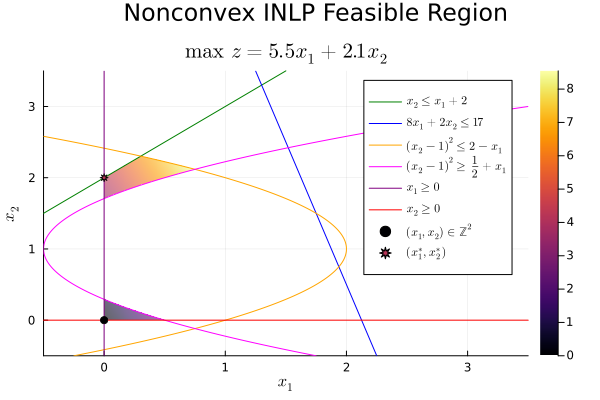

In [2]:
plot_incnlp(; sol = incnlp_x)

We are able to solve non-convex MINLP problems. However, the complexity of these problems leads to significant computational challenges that need to be tackled.


## References

- [JuMP documentation](https://jump.dev/JuMP.jl/stable/)
- [HiGHS](https://highs.dev/)
- [SCIP](https://www.scipopt.org/)


## Commercial solver installation

### Gurobi
Gurobi offers free academic licenses for students, faculty, and staff at recognized degree-granting institutions, and the current academic options include named-user, WLS, and site-license workflows. Because license types and setup steps change over time, use the current official pages for both eligibility and installation details:
- Academic licenses: https://www.gurobi.com/features/academic-cloud-license/
- License setup: https://support.gurobi.com/hc/en-us/articles/12872879801105-How-do-I-retrieve-and-set-up-a-Gurobi-license

### BARON
BARON remains a leading global MINLP solver, but its academic licensing is more restrictive: most academic users use discounted academic pricing, while free licenses are limited to specific partner-university programs listed on the vendor site. Since these terms can change, check the current license and FAQ pages before planning coursework around BARON:
- Licenses: https://minlp.com/baron-licenses
- FAQ: https://minlp.com/baron-frequently-asked-questions
